<a href="https://colab.research.google.com/github/SukhmanpreetKaurManes/My-learnings-from-Machine-Learning-with-Python-book/blob/main/RNN_Implimentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating a model for time series data.RNN is implemented through LSTM

Objective : Predict trend of diesel prices in Delhi

In [37]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [38]:
dataset_train = pd.read_csv('/content/Diesel_Price_Train.csv')
training_set = dataset_train.iloc[:,1:2].values

In [39]:
#Feature Scaling
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# Display the first few scaled values to confirm
print(training_set_scaled[:5])

[[0.01001252]
 [0.01001252]
 [0.        ]
 [0.        ]
 [0.        ]]


In [40]:
#Creating empty lists for developing the data structure with 120 timestamps and 1 output
x_train = []
y_train = []
for i in range(120,1246):
  x_train.append(training_set_scaled[i-120:i,0])
  y_train.append(training_set_scaled[i,0])

Reshaping the dataset because input to LSTM layers should be 3-D.

In [41]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

In [42]:
x_train.shape

(1126, 120, 1)

Building the RNN

In [43]:
#Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

In [44]:
#Initializing the RNN
regressor = Sequential()

In [45]:
#Adding first LSTM layers and some dropout regularization
regressor.add(LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)))
regressor.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
#Adding more LSTM and dropout regularization
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50,return_sequences=False))
regressor.add(Dropout(0.2))

In [47]:
#Add ouptput layer
regressor.add(Dense(units = 1))

In [48]:
#Compiling the RNN
regressor.compile(optimizer='adam',loss='mean_squared_error')

In [49]:
#Fitting RNN to training set
regressor.fit(x_train,y_train,epochs=100,batch_size=32)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0041
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.6268e-04
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.4976e-04
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.7307e-04
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.8022e-04
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 4.5228e-04
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 3.6396e-04
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.8946e-04
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.8983e-04
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.5379e-04
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.3257e-04
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.7478e-04
Epoch 13/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.5038e-04
Epoch 14/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.5383e-04
Epoch

In [50]:
# Making the predictions and visualizing results
# getting the real diesel price
dataset_test = pd.read_csv('/content/Diesel_Price_Test.csv')
diesel_price = dataset_test.iloc[:,1:2].values

Preparing test data in desired data structure for feeding to model

In [51]:
dataset_total = pd.concat((dataset_train["Delhi Diesel Price"],dataset_test['Delhi Diesel Price']),axis=0)
inputs = dataset_total[len(dataset_total)-len(dataset_test)-120:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [52]:
#Creating desired 3D structure for test data
X_test = []
# The loop should go up to the length of 'inputs', and the window size should match x_train (120)
for i in range(120,len(inputs)):
  X_test.append(inputs[i-120:i,0]) # Corrected: Using a window of 120

In [53]:
#Converting X_test to array and creating 3D structure
X_test = np.array(X_test)
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [54]:
#Making the predictions
predicted_price = regressor.predict(X_test)
predicted_price = sc.inverse_transform(predicted_price)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


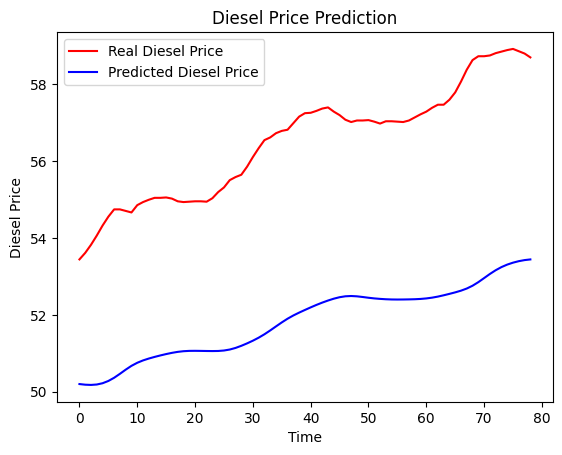

In [55]:
#Visualizing the results
plt.plot(diesel_price,color='red',label='Real Diesel Price')
plt.plot(predicted_price,color='blue',label='Predicted Diesel Price')
plt.title('Diesel Price Prediction')
plt.xlabel('Time')
plt.ylabel('Diesel Price')
plt.legend()
plt.show()